In [16]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

In [17]:
# 1. Fetch real-world financial data (S&P 500 ETF)
ticker = "NVDA"
print(f"Downloading historical data for {ticker}...")
data = yf.download(ticker, start="2015-01-01")

# Calculate daily log returns and annualized volatility (21-day rolling window)
# Assume daily returns are approximately independent with constant variance
# Var over N days = N × Var daily, Std dev over N days = sqrt(N) × Std dev daily
# There are about N=252 trading days in a year
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Volatility'] = data['Log_Return'].rolling(window=21).std() * np.sqrt(252)

# Drop missing values from rolling calculations
df = data.dropna().copy()

df.head(10)

[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume,Log_Return,Volatility
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,
Date,,,,,,,
2015-02-03,0.481944,0.482423,0.471159,0.473556,183468000,0.024668,0.335584
2015-02-04,0.483142,0.488654,0.479068,0.480506,181516000,0.002483,0.329898
2015-02-05,0.491051,0.491290,0.483142,0.483621,140448000,0.016236,0.312793
2015-02-06,0.488894,0.496323,0.486737,0.490571,210524000,-0.004402,0.313268
2015-02-09,0.488414,0.489852,0.482902,0.486018,273944000,-0.000981,0.288106
2015-02-10,0.502075,0.502314,0.486737,0.488894,226204000,0.027585,0.302201
2015-02-11,0.498720,0.503273,0.495365,0.503273,320832000,-0.006705,0.299190
2015-02-12,0.534428,0.539221,0.524123,0.527238,676904000,0.069153,0.376895


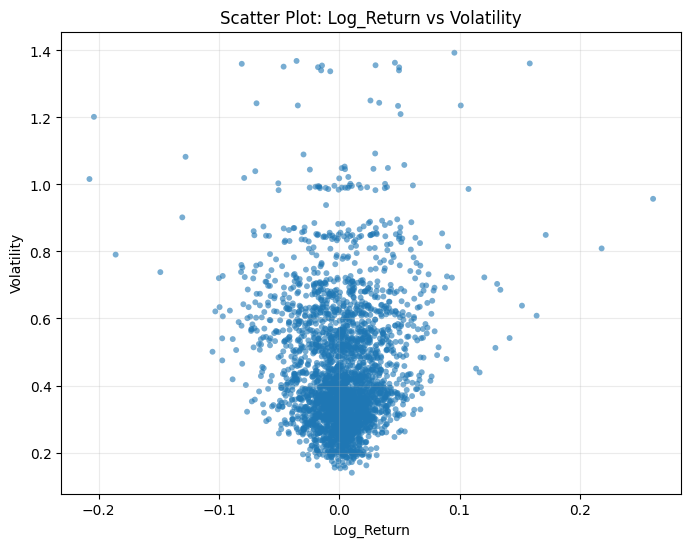

In [18]:
# Scatter plot: Log_Return vs Volatility
x = pd.to_numeric(df['Log_Return'].squeeze(), errors='coerce')
y = pd.to_numeric(df['Volatility'].squeeze(), errors='coerce')
mask = x.notna() & y.notna()

plt.figure(figsize=(8, 6))
plt.scatter(x[mask], y[mask], alpha=0.6, s=18, edgecolor='none')
plt.xlabel('Log_Return')
plt.ylabel('Volatility')
plt.title('Scatter Plot: Log_Return vs Volatility')
plt.grid(alpha=0.25)
plt.show()

In [19]:
# 2. Prepare the feature matrix (using returns and volatility as our features)
X = df[['Log_Return', 'Volatility']].values
nregimes = 2

# 3. Fit the Gaussian Mixture Model (we assume nregimes states)
print("Fitting Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=nregimes, covariance_type='full', random_state=42)
gmm.fit(X)


# Print the parameters of the nregimes Gaussian distributions and mixing coefficients
print("\nGaussian Mixture Model Parameters:")
print(f"Mixing coefficients (weights): {gmm.weights_}")
print(f"\nMeans:\n{gmm.means_}")
print(f"\nCovariances:\n{gmm.covariances_}")



Fitting Gaussian Mixture Model...

Gaussian Mixture Model Parameters:
Mixing coefficients (weights): [0.62311069 0.37688931]

Means:
[[0.00301452 0.34074911]
 [0.00068067 0.61315666]]

Covariances:
[[[0.00033618 0.00011485]
  [0.00011485 0.00692479]]

 [[0.00187846 0.00025748]
  [0.00025748 0.03656099]]]


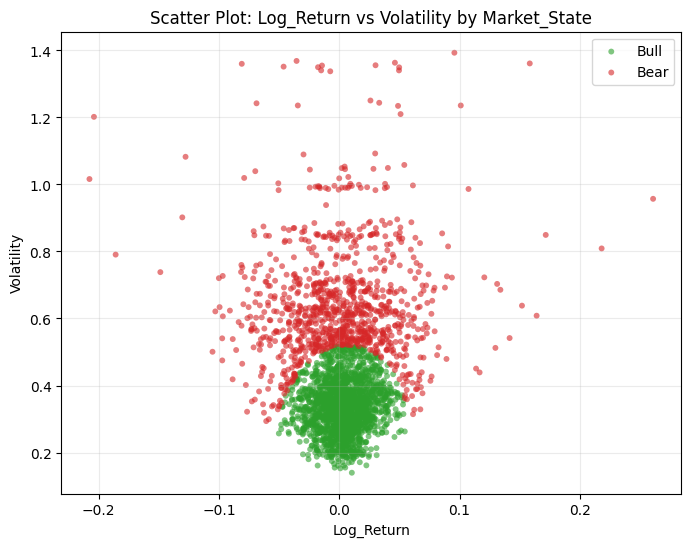

In [20]:
# Predict market states (0 or 1)
df['Regime'] = gmm.predict(X)

# Inspect the cluster means of Log_Returns
means = gmm.means_
returns_mean_cluster_0 = means[0, 0]
returns_mean_cluster_1 = means[1, 0]

# Bull regime will have a higher mean log return
if returns_mean_cluster_0 > returns_mean_cluster_1:
    bull_label = 0
    bear_label = 1
else:
    bull_label = 1
    bear_label = 0

df['Market_State'] = df['Regime'].map({bull_label: 'Bull', bear_label: 'Bear'})

# Scatter plot with different colors for each market state
plot_df = df[['Log_Return', 'Volatility', 'Market_State']].dropna().copy()
state_colors = {'Bull': 'tab:green', 'Bear': 'tab:red'}

plt.figure(figsize=(8, 6))
for state, color in state_colors.items():
    grp = plot_df[plot_df['Market_State'] == state]
    if not grp.empty:
        plt.scatter(
            grp['Log_Return'],
            grp['Volatility'],
            alpha=0.6,
            s=18,
            edgecolor='none',
            color=color,
            label=state,
        )

plt.xlabel('Log_Return')
plt.ylabel('Volatility')
plt.title('Scatter Plot: Log_Return vs Volatility by Market_State')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


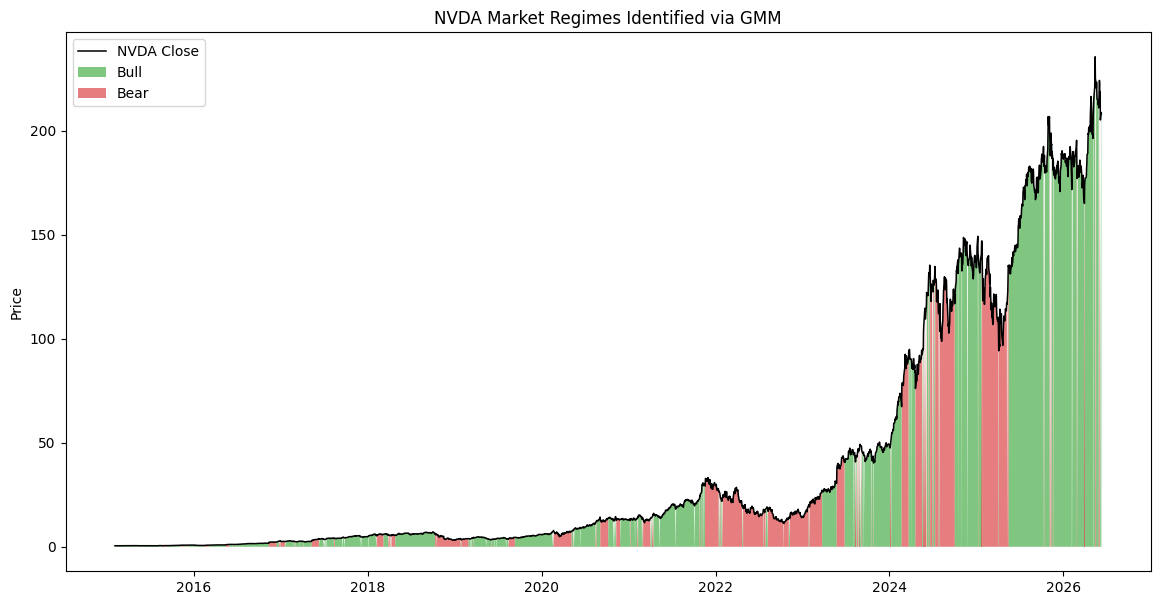


GMM Cluster Characteristics:
                         Means (Log Return, Volatility)  \
Cluster 0  [0.0030145155629097164, 0.34074910628466726]   
Cluster 1   [0.0006806717813200674, 0.6131566589924565]   

                                                 Covariances  
Cluster 0  [[0.0003361818311718641, 0.0001148488472623777...  
Cluster 1  [[0.001878462870660879, 0.00025748347280332056...  


In [27]:
# 5. Visualize the regimes over time
fig, ax1 = plt.subplots(figsize=(14, 7))
from matplotlib.patches import Patch

# Ensure Close is a 1D numeric series (yfinance may return a DataFrame-like Close column).
close_series = df['Close']
if isinstance(close_series, pd.DataFrame):
    close_series = close_series.iloc[:, 0]
close_series = pd.to_numeric(close_series, errors='coerce').astype(float)

# Plot the stock price
price_line, = ax1.plot(df.index, close_series, label=f'{ticker} Close', color='black', linewidth=1.1, zorder=3)
ax1.set_ylabel('Price', color='black')

# Reuse the same Bull/Bear colors as the scatter plot
state_colors = {'Bull': 'tab:green', 'Bear': 'tab:red'}

# Use Market_State when available, otherwise fall back to Regime
if 'Market_State' in df.columns:
    regime_series = df['Market_State'].astype(object)
else:
    regime_series = df['Regime'].astype(object)
    if pd.api.types.is_numeric_dtype(regime_series):
        regime_series = regime_series.map({bull_label: 'Bull', bear_label: 'Bear'})

# Shade only the area under the close curve for each regime
for label, color in state_colors.items():
    in_state = regime_series.eq(label).to_numpy()
    if in_state.any():
        ax1.fill_between(
            df.index,
            0,
            close_series,
            where=in_state,
            facecolor=color,
            alpha=0.6,
            interpolate=True,
            linewidth=0,
            zorder=0,
        )

ax1.set_title(f'{ticker} Market Regimes Identified via GMM')
legend_handles = [
    price_line,
    Patch(facecolor=state_colors['Bull'], alpha=0.6, label='Bull'),
    Patch(facecolor=state_colors['Bear'], alpha=0.6, label='Bear'),
]
ax1.legend(handles=legend_handles, loc='upper left')
plt.show()

# 6. View the probabilistic characteristics of the clusters
cluster_index = [f'Cluster {i}' for i in range(nregimes)]
print('\nGMM Cluster Characteristics:')
print(pd.DataFrame({
    'Means (Log Return, Volatility)': gmm.means_.tolist(),
    'Covariances': gmm.covariances_.tolist()
}, index=cluster_index))
